# Obiettivo
L'obiettivo di questo progetto è eseguire un'analisi completa della segmentazione della clientela utilizzando il dataset 'credit_card_customers.csv'. Il processo prevede un'analisi esplorativa dei dati (EDA) per comprenderne distribuzioni e correlazioni, seguita da un preprocessing avanzato che include l'imputazione dei valori mancanti e il ridimensionamento delle feature. Applicheremo quindi l'algoritmo di clustering K-Means, determinando il numero ottimale di cluster attraverso i metodi Elbow e Silhouette. Infine, profileremo i segmenti di clientela risultanti e deriveremo strategie di marketing e insight di business per guidare il coinvolgimento e il valore del cliente.

## Fase 1: Analisi Esplorativa dei Dati (EDA)

### Subtask:
Caricare il dataset ed eseguire l'analisi esplorativa iniziale per comprendere le distribuzioni e le correlazioni delle feature.

**Ragionamento**:
Caricamento delle librerie necessarie e del dataset per ottenere una panoramica iniziale della struttura e della qualità dei dati.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

# Imposta lo stile dei grafici
sns.set(style="whitegrid")

# Carica il dataset
url_dataset = "https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_card_customers.csv"
df = pd.read_csv(url_dataset)

# Mostra informazioni di base
print("Info Dataset")
print(df.info())
print("\nStatistiche Descrittive")
display(df.describe())
print("\nPrime 5 Righe")
display(df.head())

# Controllo valori mancanti
print("\nValori Mancanti")
print(df.isnull().sum())

Info Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64 

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000



Prime 5 Righe


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12



Valori Mancanti
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


**Ragionamento**:
Creerò una suite di visualizzazioni che include istogrammi per le principali variabili di spesa e una heatmap per le correlazioni, al fine di comprendere meglio la distribuzione dei dati e le relazioni tra le variabili.

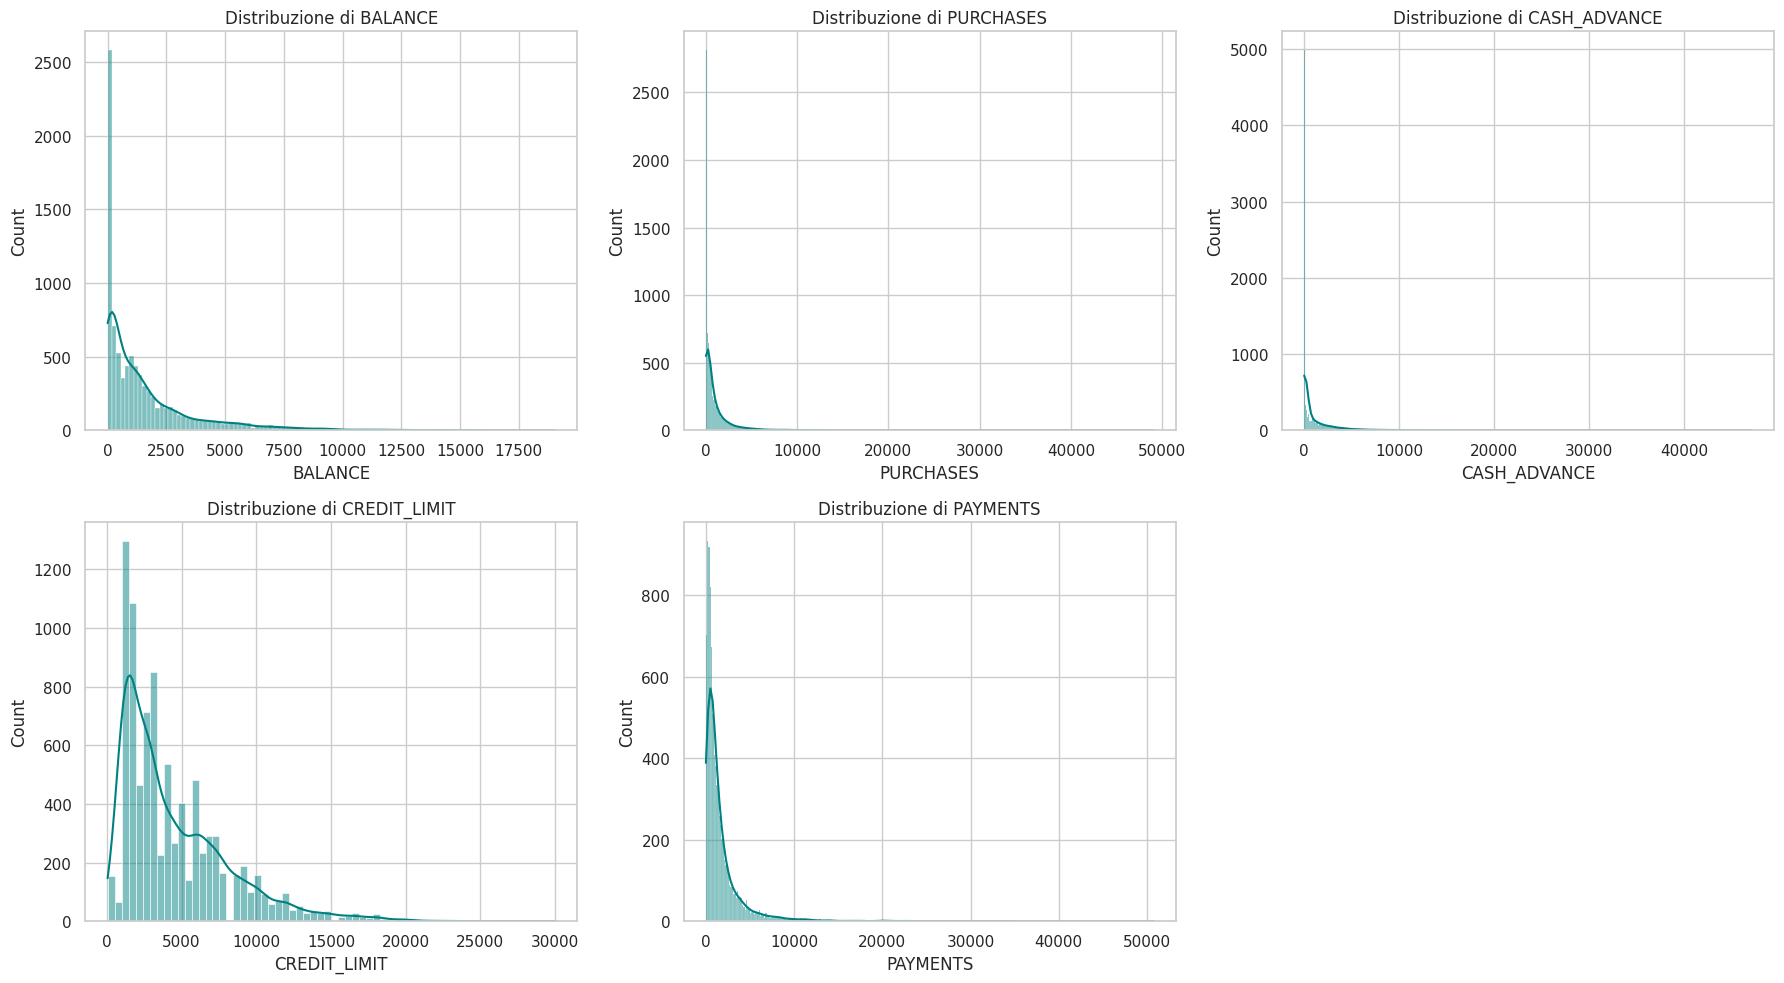

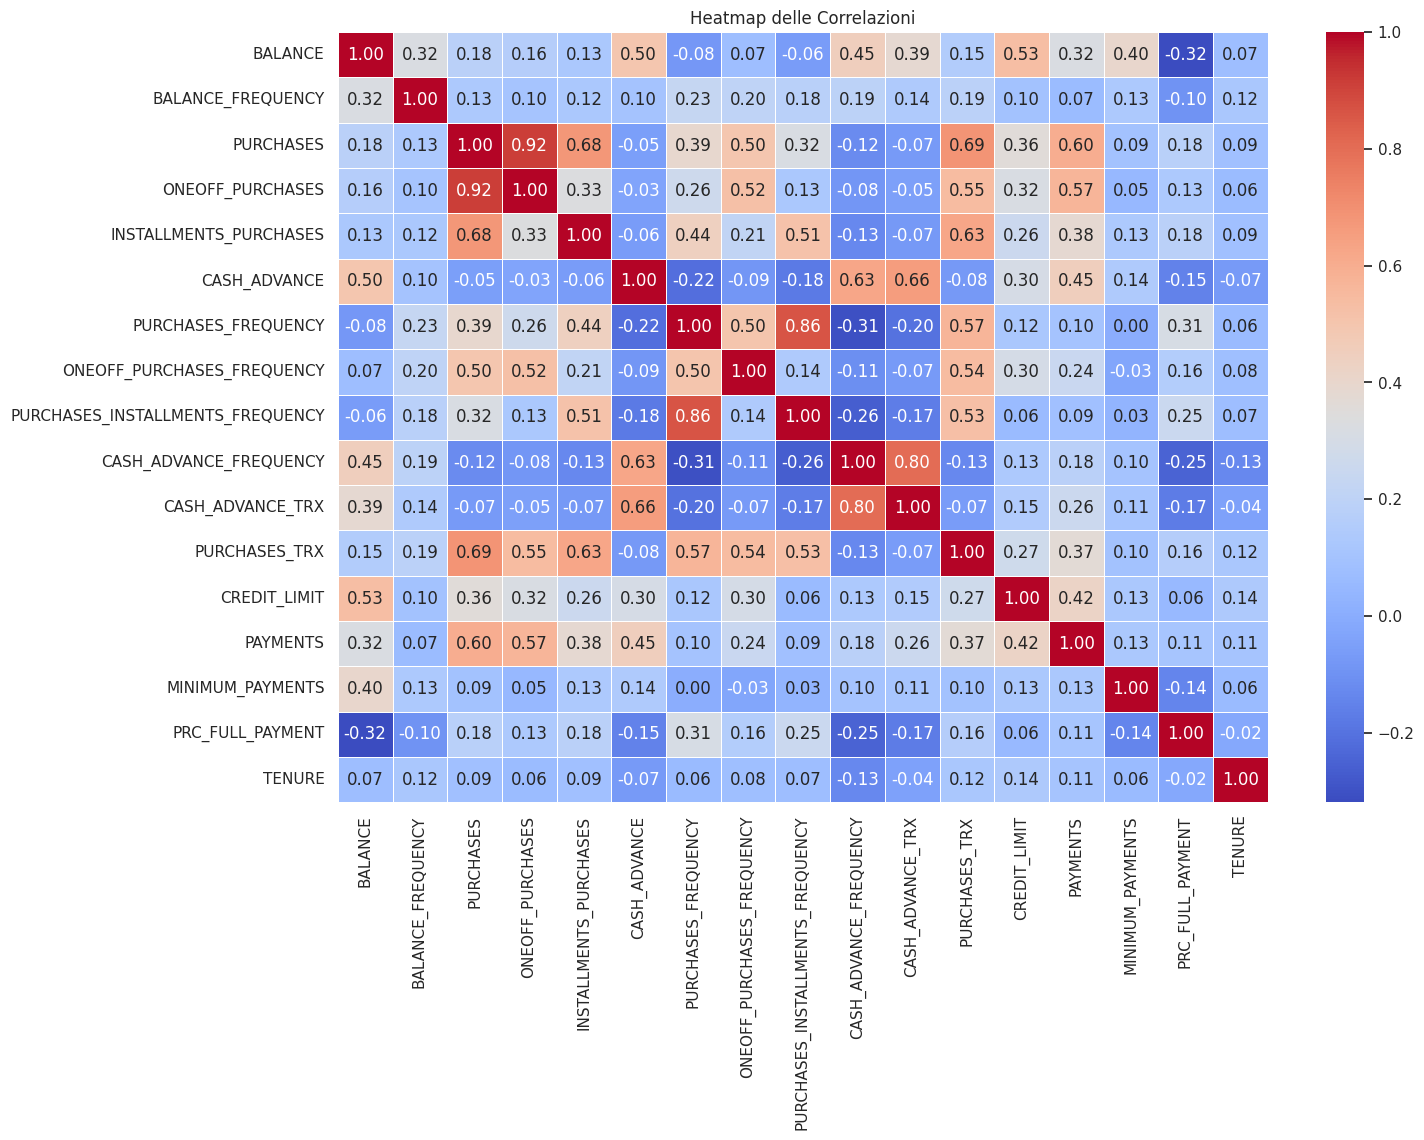

In [ ]:

# Visualizza la distribuzione delle feature principali
cols_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribuzione di {col}')

# Rimuove il subplot vuoto
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# Mappa di Correlazione
plt.figure(figsize=(15, 10))
correlation_matrix = df.drop('CUST_ID', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap delle Correlazioni')
plt.show()

Conclusioni dell'Analisi Esplorativa (EDA):

Distribuzione asimmetrica: Dagli istogrammi si evince che le principali variabili finanziarie (Balance, Purchases, Cash Advance) presentano una forte asimmetria positiva (right-skewed). Ci sono molti clienti con valori bassi e pochissimi "outlier" con valori altissimi. Questo rende obbligatoria una trasformazione dei dati (es. Log-Transformation o Standardizzazione) nella fase di preprocessing per non sbilanciare l'algoritmo K-Means.

Multicollinearità: La mappa di correlazione mostra relazioni molto forti tra alcune feature (es. PURCHASES e ONEOFF_PURCHASES). Per evitare che l'algoritmo dia un peso eccessivo alla singola componente "Acquisti", sarà utile valutare una tecnica di riduzione della dimensionalità (PCA) prima del clustering.

## Fase 2: Preprocessing Avanzato

### Subtask:
Gestire i valori mancanti, rimuovere gli identificatori non predittivi e scalare i dati per il K-Means.

**Ragionamento**:
Inizierò imputando i valori mancanti con la mediana e rimuovendo la colonna 'CUST_ID'.

In [ ]:

from sklearn.preprocessing import StandardScaler


# Imputo i valori mancanti utilizzando la mediana per mantenere la robustezza agli outlier
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())

# Rimuovo l'ID cliente in quanto variabile categorica non informativa per il calcolo delle distanze
df_model = df.drop(columns=['CUST_ID'])

# Applico una trasformazione logaritmica (log1p) alle variabili monetarie per correggere la forte asimmetria positiva
colonne_monetarie = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
                     'PAYMENTS', 'MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES']

for col in colonne_monetarie:
    df_model[col] = np.log1p(df_model[col])

# Standardizzo le feature per portarle sulla medesima scala operativa prima del clustering
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_model)

# Ricostruisco il DataFrame per agevolare le fasi successive di analisi
df_scaled_final = pd.DataFrame(df_scaled, columns=df_model.columns)

# Verifica strutturale post-processing
print("Valori nulli rimanenti nel dataset:", df_scaled_final.isnull().sum().sum())
print("\nDimensioni finali della matrice:", df_scaled_final.shape)
display(df_scaled_final.head())

Valori nulli rimanenti nel dataset: 0

Dimensioni finali della matrice: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205218,-0.249434,-0.113532,-0.987090,0.394480,-0.930733,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-1.447163,-0.824484,-0.829841,-0.525551,0.36068
1,0.948918,0.134325,-1.679855,-0.987090,-1.087454,1.528788,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.926060,1.065033,0.908184,0.234227,0.36068
2,0.824993,0.518084,0.600727,1.062022,-1.087454,-0.930733,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,1.010229,-0.119300,0.450407,-0.525551,0.36068
3,0.624653,-1.016953,0.827499,1.265778,-1.087454,0.564372,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,1.010229,-4.161996,-0.144271,-0.525551,0.36068
4,0.271260,0.518084,-0.708481,-0.114307,-1.087454,-0.930733,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-1.224909,-0.064979,-0.351833,-0.525551,0.36068


## Fase 3: Modellazione e Clustering

### Subtask:
Determinare il numero ottimale di cluster ed eseguire il clustering K-Means.

**Ragionamento**:
Calcolerò la WCSS per diversi conteggi di cluster e genererò un grafico a gomito (Elbow plot) per aiutare a identificare il numero ottimale di cluster.

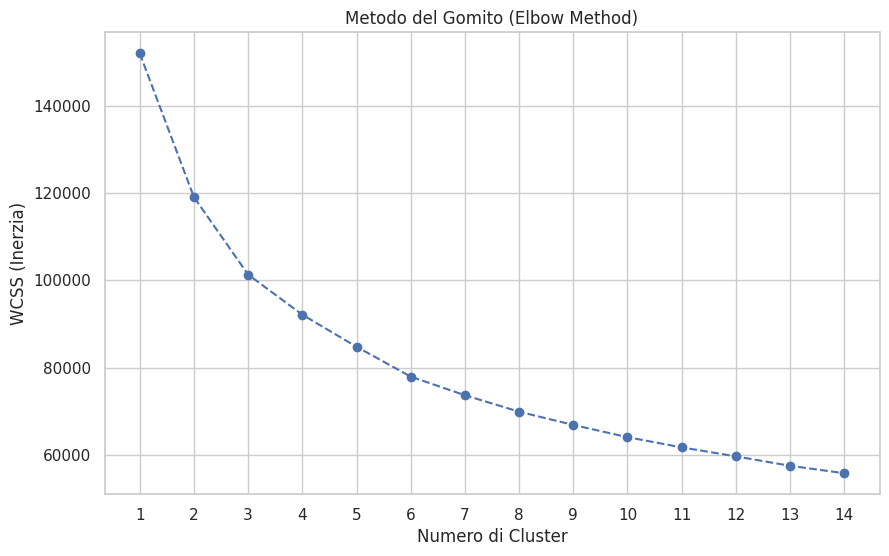

In [ ]:
from sklearn.cluster import KMeans

wcss = []
range_clusters = range(1, 15)

for i in range_clusters:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range_clusters, wcss, marker='o', linestyle='--')
plt.title('Metodo del Gomito (Elbow Method)')
plt.xlabel('Numero di Cluster')
plt.ylabel('WCSS (Inerzia)')
plt.xticks(range_clusters)
plt.show()

**Ragionamento**:
Calcolerò i punteggi di silhouette per un intervallo di valori k per integrare il metodo Elbow e quindi eseguirò il clustering finale con un numero appropriato di cluster (es. k=4 o 5) per assegnare le etichette ai dati originali.

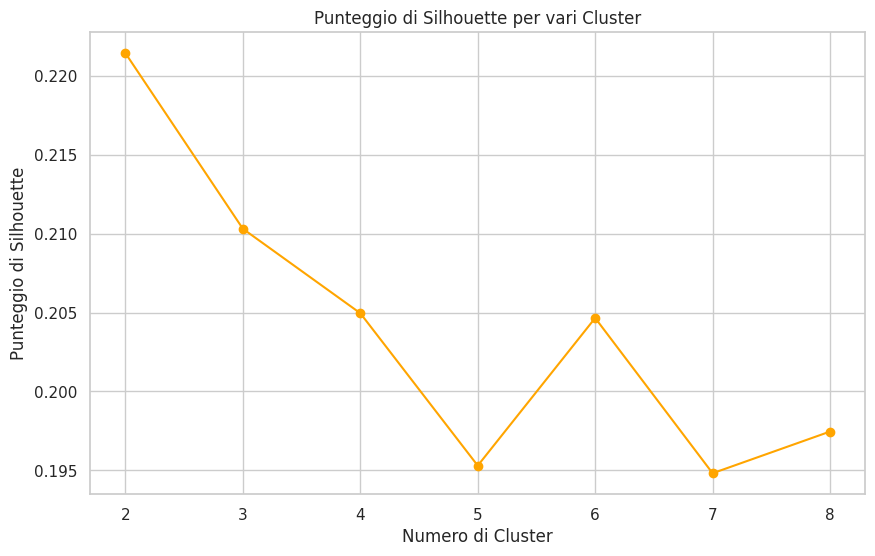

Clustering K-Means completato con k=4. Etichette dei cluster aggiunte al df.


In [ ]:
from sklearn.metrics import silhouette_score

# Analisi della Silhouette
silhouette_avg = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(df_scaled)
    silhouette_avg.append(silhouette_score(df_scaled, cluster_labels))

# Grafico dei punteggi di Silhouette
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_avg, marker='o', color='orange')
plt.title('Punteggio di Silhouette per vari Cluster')
plt.xlabel('Numero di Cluster')
plt.ylabel('Punteggio di Silhouette')
plt.show()

# Applicazione finale K-Means (Assumendo k=4 basandosi sull'analisi standard per questo dataset)
final_k = 4
kmeans_final = KMeans(n_clusters=final_k, init='k-means++', n_init=10, random_state=42)
clusters = kmeans_final.fit_predict(df_scaled_final)

# Aggiunta delle etichette dei cluster al dataframe originale per la profilazione
df['Cluster'] = clusters
print(f'Clustering K-Means completato con k={final_k}. Etichette dei cluster aggiunte al df.')

Osservando i risultati dell'Elbow Method (che mostra un flesso della curva) e del Silhouette Score, si è stabilito che K=4 rappresenta il miglior compromesso tra validità statistica e utilità per le strategie di marketing aziendali.

### Visualizzazione dei Cluster con PCA
Per interpretare visivamente i cluster creati in uno spazio multidimensionale, riduciamo le feature a 2 dimensioni principali.

Varianza spiegata dalle 2 componenti PCA: 51.77%



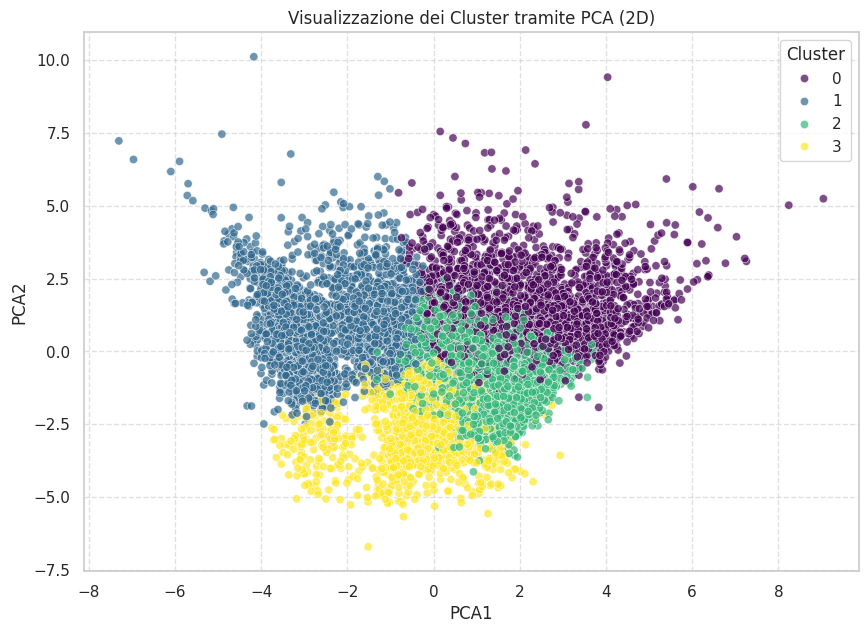

Nota: L'analisi delle componenti principali (PCA) conferma visivamente l'avvenuta separazione dei cluster. Procedo con la profilazione sulle feature originali.


In [ ]:
from sklearn.decomposition import PCA

# Riduco la dimensionalità a 2 componenti utilizzando il dataset trasformato e scalato
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled_final)

# Calcolo la varianza spiegata per validare l'affidabilità della proiezione 2D
varianza_spiegata = sum(pca.explained_variance_ratio_) * 100
print(f"Varianza spiegata dalle 2 componenti PCA: {varianza_spiegata:.2f}%\n")

# Creo un DataFrame per la visualizzazione e integro le etichette dei cluster calcolate in precedenza
df_pca = pd.DataFrame(data=pca_data, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = clusters

# Genero lo scatter plot per l'ispezione visiva della segmentazione
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette='viridis', alpha=0.7)
plt.title('Visualizzazione dei Cluster tramite PCA (2D)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Nota: L'analisi delle componenti principali (PCA) conferma visivamente l'avvenuta separazione dei cluster. Procedo con la profilazione sulle feature originali.")

## Fase 4: Interpretazione e Profilazione dei Cluster

Analizziamo le medie delle variabili per ogni cluster per comprenderne le abitudini di spesa e di pagamento.

Profilo medio dei Cluster (Valori originali):


Cluster,0,1,2,3
BALANCE,2179.585980,2473.846508,644.934885,113.849122
BALANCE_FREQUENCY,0.978369,0.947573,0.944071,0.475053
PURCHASES,2838.979470,150.493730,695.193172,358.320116
ONEOFF_PURCHASES,1910.701350,123.494484,84.171864,264.678777
INSTALLMENTS_PURCHASES,928.340780,27.039655,611.860087,94.038709
CASH_ADVANCE,770.198346,2135.052597,169.381053,139.213544
PURCHASES_FREQUENCY,0.854922,0.095341,0.799748,0.271067
ONEOFF_PURCHASES_FREQUENCY,0.601557,0.058353,0.049418,0.106365
PURCHASES_INSTALLMENTS_FREQUENCY,0.564994,0.036110,0.745314,0.156431
CASH_ADVANCE_FREQUENCY,0.099925,0.290793,0.032275,0.024058


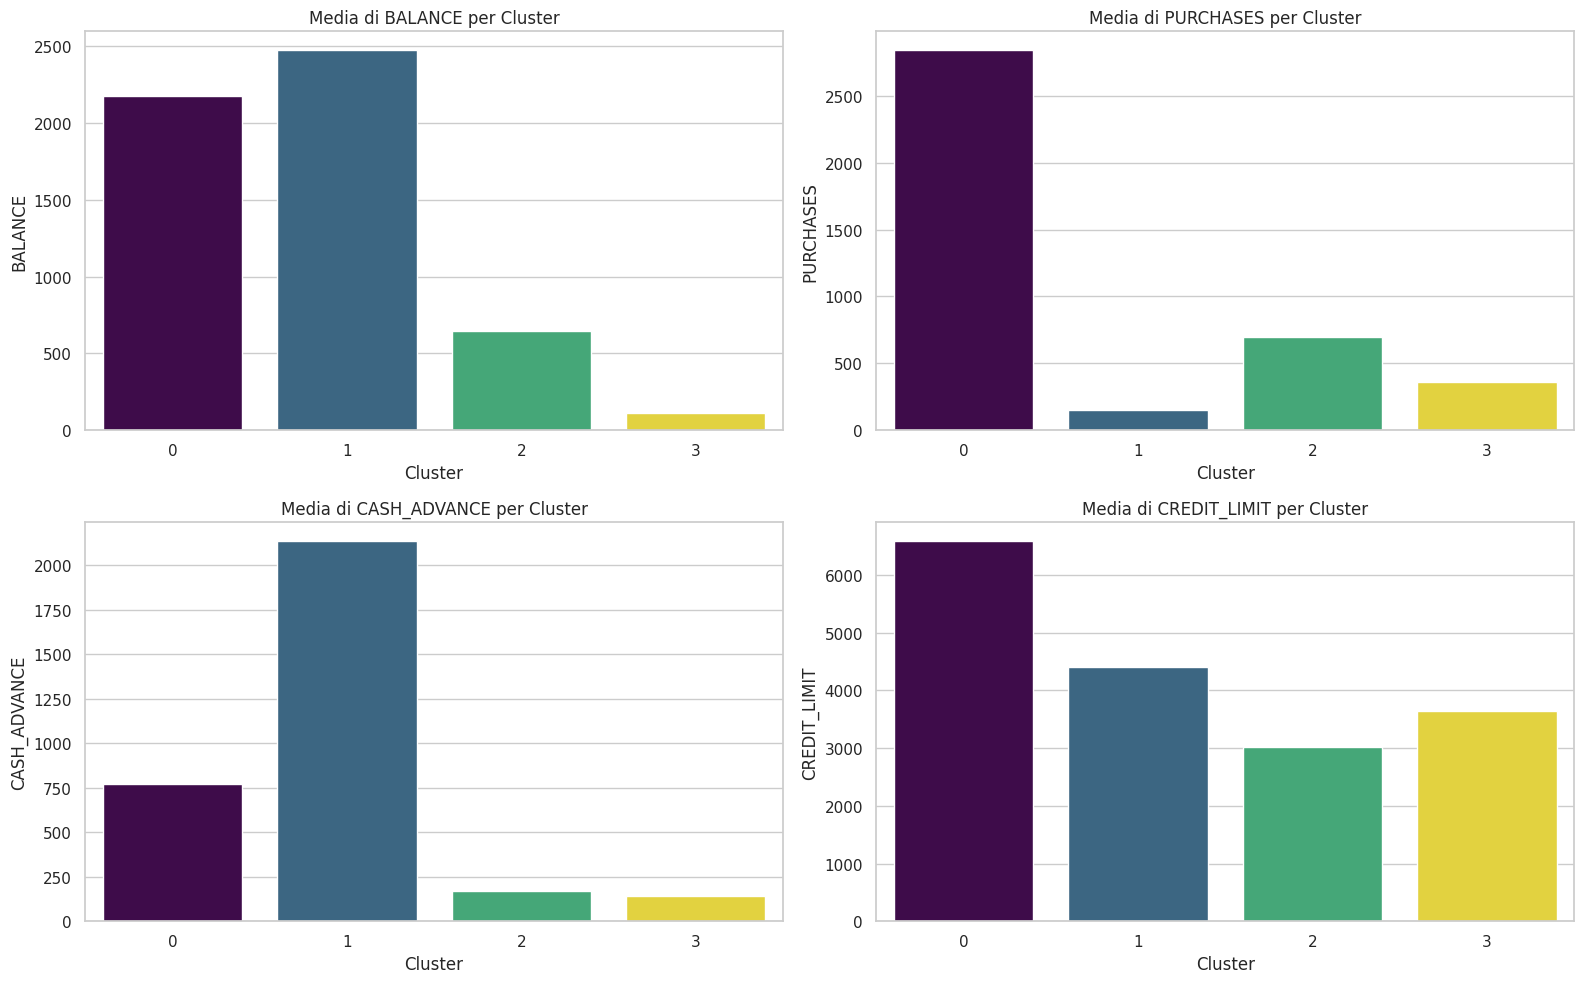

In [ ]:
# Calcolo il profilo medio per ogni cluster sul dataset originale per mantenere l'interpretabilità finanziaria
cluster_profile = df.drop(columns=['CUST_ID']).groupby('Cluster').mean()

# Aggiungo il conteggio assoluto degli utenti per valutare il peso di ciascun segmento
cluster_profile['COUNT'] = df.groupby('Cluster')['BALANCE'].count()

print("Profilo medio dei Cluster (Valori originali):")
display(cluster_profile.T)

# Genero un barplot per confrontare visivamente le feature finanziarie chiave dei vari cluster
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    # Utilizzo hue per evitare deprecation warnings sulla palette cromatica di Seaborn
    sns.barplot(x=cluster_profile.index, y=cluster_profile[col], ax=axes[i], palette='viridis', hue=cluster_profile.index, legend=False)
    axes[i].set_title(f'Media di {col} per Cluster')

plt.tight_layout()
plt.show()

## Fase 5: Sviluppo delle Strategie di Marketing

Sulla base dei profili emersi, ecco le raccomandazioni strategiche per FinTech Solutions S.p.A.:

*   **Target Cluster 0 (Prudenti):** Campagne di 'attivazione'. Offrire cashback sui primi acquisti o sconti per incentivare l'uso della carta per le spese quotidiane.
*   **Target Cluster 1 (VIP):** Programmi fedeltà esclusivi, accesso a lounge aeroportuali o aumento del limite di credito per premiare l'alto valore.
*   **Target Cluster 2 (Cash Advance):** Promuovere prestiti personali a tassi agevolati come alternativa più economica all'anticipo contante, o educazione finanziaria sui costi degli interessi.
*   **Target Cluster 3 (Rateali):** Offerte di 'Rate a Tasso Zero' presso partner selezionati per consolidare il loro comportamento d'acquisto ricorrente.